In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('D:/Downloads/archive (1)/airline_ticket_prices_dataset.csv')

In [3]:
df

,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD
0,1,Saudia,Mumbai,Paris,2643,Economy,28,555.30
1,2,Etihad,Istanbul,Jeddah,8266,Business,98,2070.27
2,3,British Airways,Dubai,Riyadh,2698,First,21,1883.11
3,4,Emirates,London,Istanbul,7956,First,24,5349.65
4,5,Qatar Airways,Doha,Dubai,1308,Business,60,516.19
...,...,...,...,...,...,...,...,...
245,246,Qatar Airways,Cairo,Paris,2389,First,33,1513.01
246,247,Turkish Airlines,Dubai,Paris,6941,First,36,4298.76
247,248,Saudia,Doha,London,7396,Business,34,3008.26
248,249,Lufthansa,Riyadh,Istanbul,8028,Business,58,2540.92


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              250 non-null    int64  
 1   Airline                250 non-null    object 
 2   Origin                 250 non-null    object 
 3   Destination            250 non-null    object 
 4   Distance_km            250 non-null    int64  
 5   Class                  250 non-null    object 
 6   Days_Before_Departure  250 non-null    int64  
 7   Price_USD              250 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 15.8+ KB


In [5]:
df.describe()

,Ticket_ID,Distance_km,Days_Before_Departure,Price_USD
count,250.000000,250.000000,250.000000,250.000000
mean,125.500000,5999.952000,59.024000,2006.059760
std,72.312977,3401.695261,33.736628,1675.067217
min,1.000000,336.000000,1.000000,106.070000
25%,63.250000,2991.750000,31.250000,818.665000
50%,125.500000,6132.500000,60.500000,1531.235000
75%,187.750000,8832.750000,86.750000,2590.357500
max,250.000000,11903.000000,118.000000,8852.690000


In [6]:
df.isnull().sum()

Ticket_ID                0
Airline                  0
Origin                   0
Destination              0
Distance_km              0
Class                    0
Days_Before_Departure    0
Price_USD                0
dtype: int64

In [7]:
df.head(5)

,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD
0,1,Saudia,Mumbai,Paris,2643,Economy,28,555.30
1,2,Etihad,Istanbul,Jeddah,8266,Business,98,2070.27
2,3,British Airways,Dubai,Riyadh,2698,First,21,1883.11
3,4,Emirates,London,Istanbul,7956,First,24,5349.65
4,5,Qatar Airways,Doha,Dubai,1308,Business,60,516.19


In [8]:
df.columns=df.columns.str.lower()

In [9]:
df

,ticket_id,airline,origin,destination,distance_km,class,days_before_departure,price_usd
0,1,Saudia,Mumbai,Paris,2643,Economy,28,555.30
1,2,Etihad,Istanbul,Jeddah,8266,Business,98,2070.27
2,3,British Airways,Dubai,Riyadh,2698,First,21,1883.11
3,4,Emirates,London,Istanbul,7956,First,24,5349.65
4,5,Qatar Airways,Doha,Dubai,1308,Business,60,516.19
...,...,...,...,...,...,...,...,...
245,246,Qatar Airways,Cairo,Paris,2389,First,33,1513.01
246,247,Turkish Airlines,Dubai,Paris,6941,First,36,4298.76
247,248,Saudia,Doha,London,7396,Business,34,3008.26
248,249,Lufthansa,Riyadh,Istanbul,8028,Business,58,2540.92


In [10]:
df['ticket_id'] = df['ticket_id'].astype('int32')
df['distance_km'] = df['distance_km'].astype('int32')
df['price_usd'] = df['price_usd'].astype('float32')
df['days_before_departure'] = df['days_before_departure'].astype('int8')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_id              250 non-null    int32  
 1   airline                250 non-null    object 
 2   origin                 250 non-null    object 
 3   destination            250 non-null    object 
 4   distance_km            250 non-null    int32  
 5   class                  250 non-null    object 
 6   days_before_departure  250 non-null    int8   
 7   price_usd              250 non-null    float32
dtypes: float32(1), int32(2), int8(1), object(4)
memory usage: 11.1+ KB


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_id              250 non-null    int32  
 1   airline                250 non-null    object 
 2   origin                 250 non-null    object 
 3   destination            250 non-null    object 
 4   distance_km            250 non-null    int32  
 5   class                  250 non-null    object 
 6   days_before_departure  250 non-null    int8   
 7   price_usd              250 non-null    float32
dtypes: float32(1), int32(2), int8(1), object(4)
memory usage: 11.1+ KB


In [13]:
### Top 5 airlines covered most distance
top_dist_airline = df.groupby('airline')['distance_km'].sum().sort_values(ascending= False)

In [14]:
print(top_dist_airline.head(5))

airline
Emirates           218178
Lufthansa          207298
Qatar Airways      205452
Saudia             203059
British Airways    199465
Name: distance_km, dtype: int32


In [15]:
## comparison between airlines and number of booking for in several class
airline_by_class = df.groupby(['airline', 'class'])['class'].count()
print(airline_by_class)

airline           class   
British Airways   Business    10
                  Economy     14
                  First       12
Emirates          Business     7
                  Economy     15
                  First       10
Etihad            Business    11
                  Economy      7
                  First        6
Flynas            Business     9
                  Economy      9
                  First        8
Lufthansa         Business    11
                  Economy     13
                  First       10
Qatar Airways     Business    11
                  Economy     10
                  First       15
Saudia            Business     7
                  Economy     12
                  First       13
Turkish Airlines  Business     9
                  Economy      9
                  First       12
Name: class, dtype: int64


In [16]:
## top 3 airlines used most
top_airlines = df.groupby('airline')['airline'].count().sort_values(ascending= False)
print(top_airlines.head(3))

airline
British Airways    36
Qatar Airways      36
Lufthansa          34
Name: airline, dtype: int64


In [17]:
## most demanded airlines 
##most_demanded_airlines = df.groupby('airline')['days_before_departure'].mean()
df['avg_book_days'] = df.groupby('airline')['days_before_departure'].transform('mean').round().astype('int')
##print(most_demanded_airlines)

In [18]:
df

,ticket_id,airline,origin,destination,distance_km,class,days_before_departure,price_usd,avg_book_days
0,1,Saudia,Mumbai,Paris,2643,Economy,28,555.299988,52
1,2,Etihad,Istanbul,Jeddah,8266,Business,98,2070.270020,71
2,3,British Airways,Dubai,Riyadh,2698,First,21,1883.109985,51
3,4,Emirates,London,Istanbul,7956,First,24,5349.649902,61
4,5,Qatar Airways,Doha,Dubai,1308,Business,60,516.190002,59
...,...,...,...,...,...,...,...,...,...
245,246,Qatar Airways,Cairo,Paris,2389,First,33,1513.010010,59
246,247,Turkish Airlines,Dubai,Paris,6941,First,36,4298.759766,60
247,248,Saudia,Doha,London,7396,Business,34,3008.260010,52
248,249,Lufthansa,Riyadh,Istanbul,8028,Business,58,2540.919922,55


In [19]:
## most demanded airlines by booking days
most_busy_airlines = df.groupby('airline')['avg_book_days'].mean().sort_values(ascending = False).head(3)
print(most_busy_airlines)

airline
Etihad      71.0
Flynas      69.0
Emirates    61.0
Name: avg_book_days, dtype: float64


In [20]:
## distance per usd per airline
df['dist_per_usd'] = (df['distance_km']/df['price_usd']).round().astype('int')
df
dist_per_usd_per_airline = df.groupby('airline')['dist_per_usd'].mean().sort_values(ascending = False)
print("most cheap airline by distance per usd spent...")
print(dist_per_usd_per_airline.head(3))

most cheap airline by distance per usd spent...
airline
Flynas      4.192308
Emirates    4.156250
Etihad      3.833333
Name: dist_per_usd, dtype: float64


In [26]:
#Route Popularity and Pricing
df['route'] = df['origin'] + ' to ' + df['destination']

# Finding the top 5 most frequent routes
top_routes = df['route'].value_counts().head(5)
print("Top 5 Most Frequent Routes:")
print(top_routes)

# Average price for these top routes
avg_route_price = df[df['route'].isin(top_routes.index)].groupby('route')['price_usd'].mean()
print("\nAverage Price for Top Routes:")
print(avg_route_price)

Top 5 Most Frequent Routes:
route
Mumbai to Paris       7
Mumbai to Istanbul    6
Paris to Cairo        6
Jeddah to Cairo       6
Doha to Cairo         6
Name: count, dtype: int64

Average Price for Top Routes:
route
Doha to Cairo         2454.486572
Jeddah to Cairo       1393.623413
Mumbai to Istanbul    2904.716797
Mumbai to Paris       2034.281372
Paris to Cairo        1580.658325
Name: price_usd, dtype: float32


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

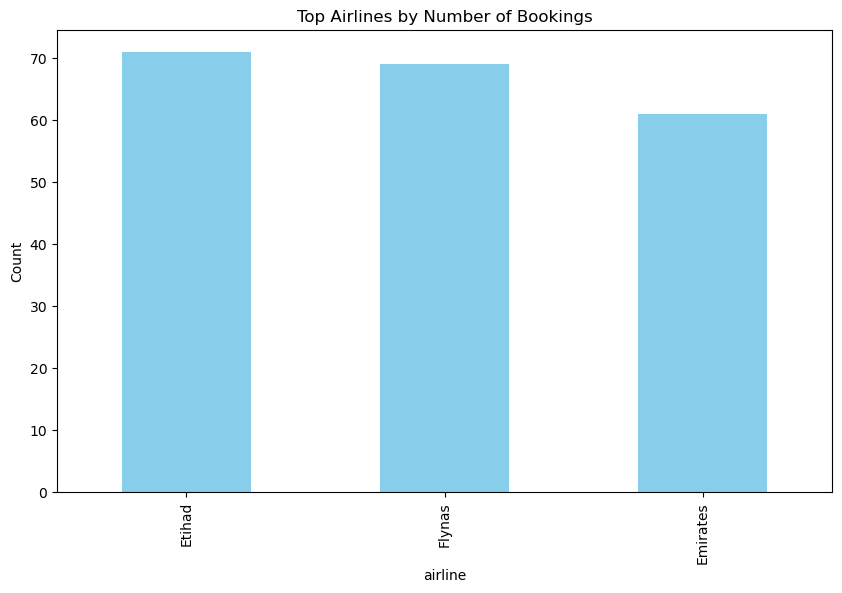

In [22]:
plt.figure(figsize=(10,6))
most_busy_airlines.plot(kind='bar', color='skyblue')
plt.title('Top Airlines by Number of Bookings')
plt.ylabel('Count')
plt.show()

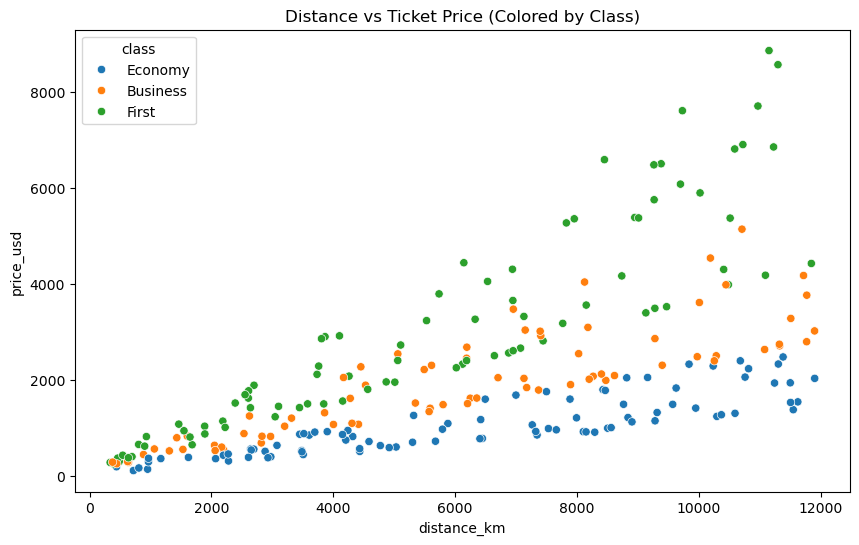

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='distance_km', y='price_usd', hue='class')
plt.title('Distance vs Ticket Price (Colored by Class)')
plt.show()

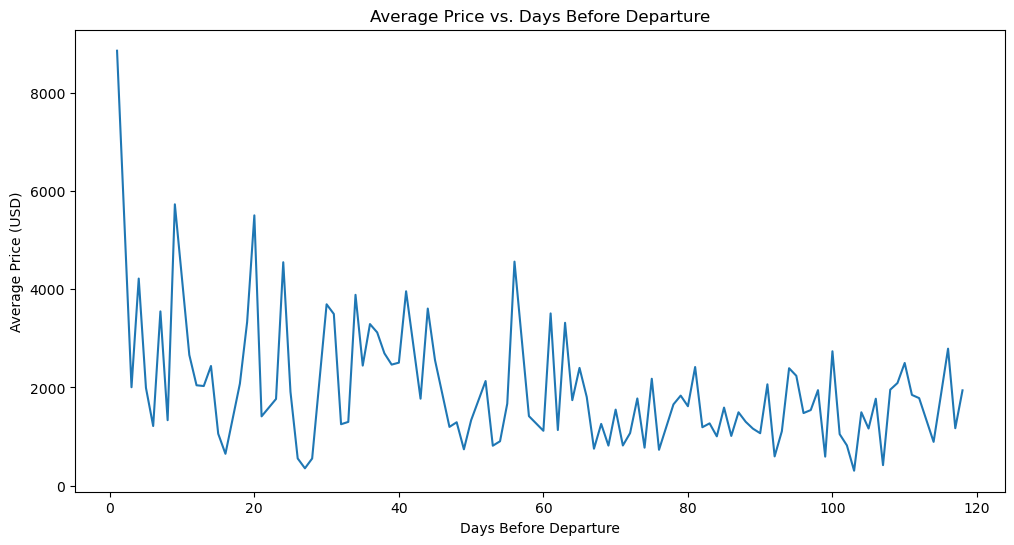

In [24]:
price_trend = df.groupby('days_before_departure')['price_usd'].mean()

plt.figure(figsize=(12,6))
price_trend.plot()
plt.title('Average Price vs. Days Before Departure')
plt.xlabel('Days Before Departure')
plt.ylabel('Average Price (USD)')
plt.show()

Average Price by Class:
class
Economy     1054.486328
Business    1939.808105
First       3048.605469
Name: price_usd, dtype: float32


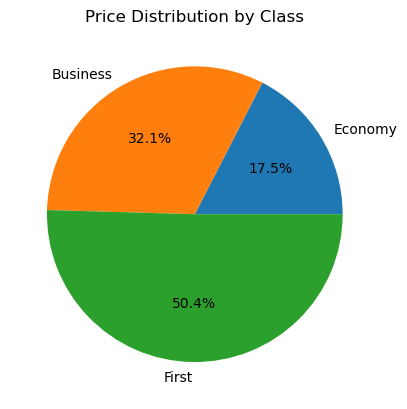

In [25]:
avg_price_class = df.groupby('class')['price_usd'].mean().sort_values()
print("Average Price by Class:")
print(avg_price_class)

# Plotting the result
avg_price_class.plot(kind='pie', autopct='%1.1f%%', title='Price Distribution by Class')
plt.ylabel('')
plt.show()

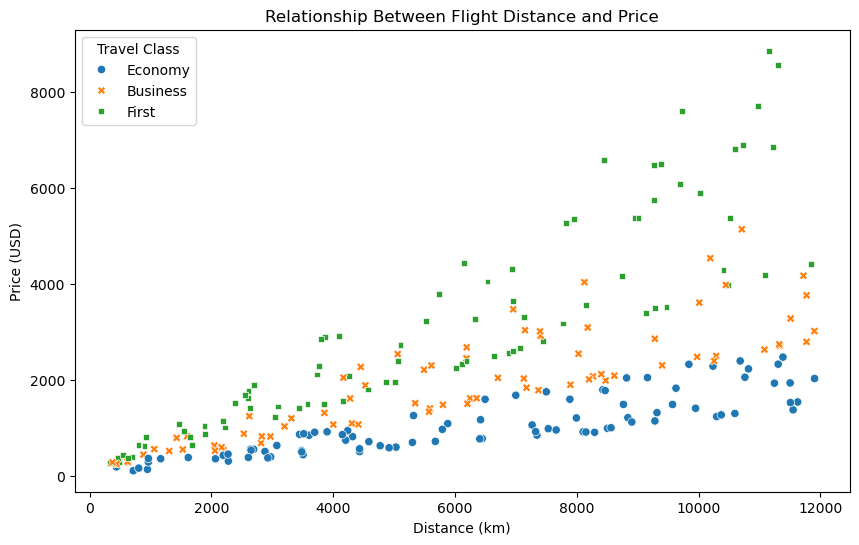

In [27]:
##Visualizing Price vs. Distance
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance_km', y='price_usd', hue='class', style='class')
plt.title('Relationship Between Flight Distance and Price')
plt.xlabel('Distance (km)')
plt.ylabel('Price (USD)')
plt.legend(title='Travel Class')
plt.show()

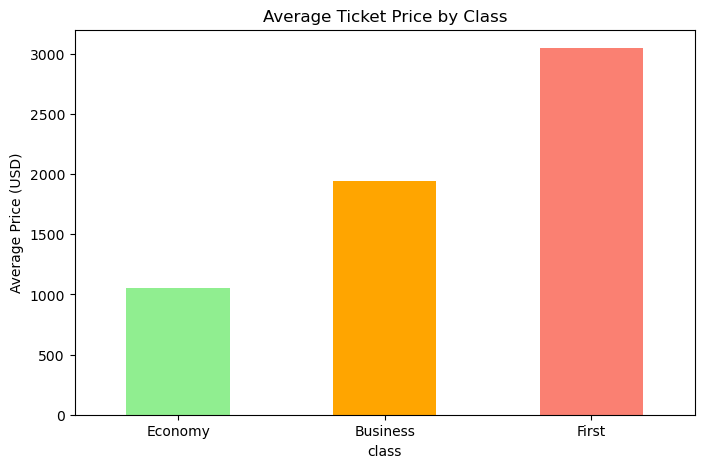

In [28]:
# Calculating average price per class
avg_price_class = df.groupby('class')['price_usd'].mean().sort_values()

# Plotting
plt.figure(figsize=(8, 5))
avg_price_class.plot(kind='bar', color=['lightgreen', 'orange', 'salmon'])
plt.title('Average Ticket Price by Class')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=0)
plt.show()

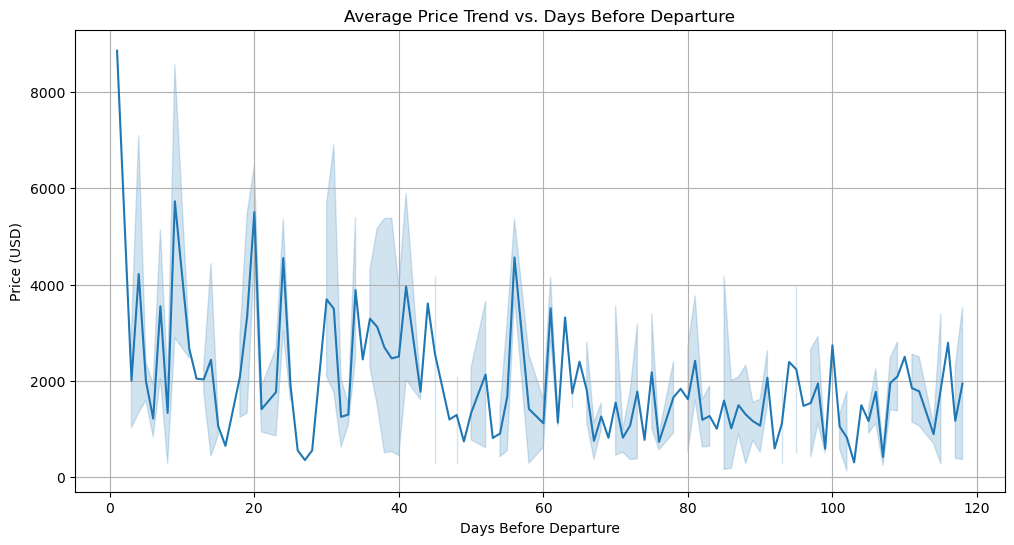

In [29]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='days_before_departure', y='price_usd')
plt.title('Average Price Trend vs. Days Before Departure')
plt.xlabel('Days Before Departure')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

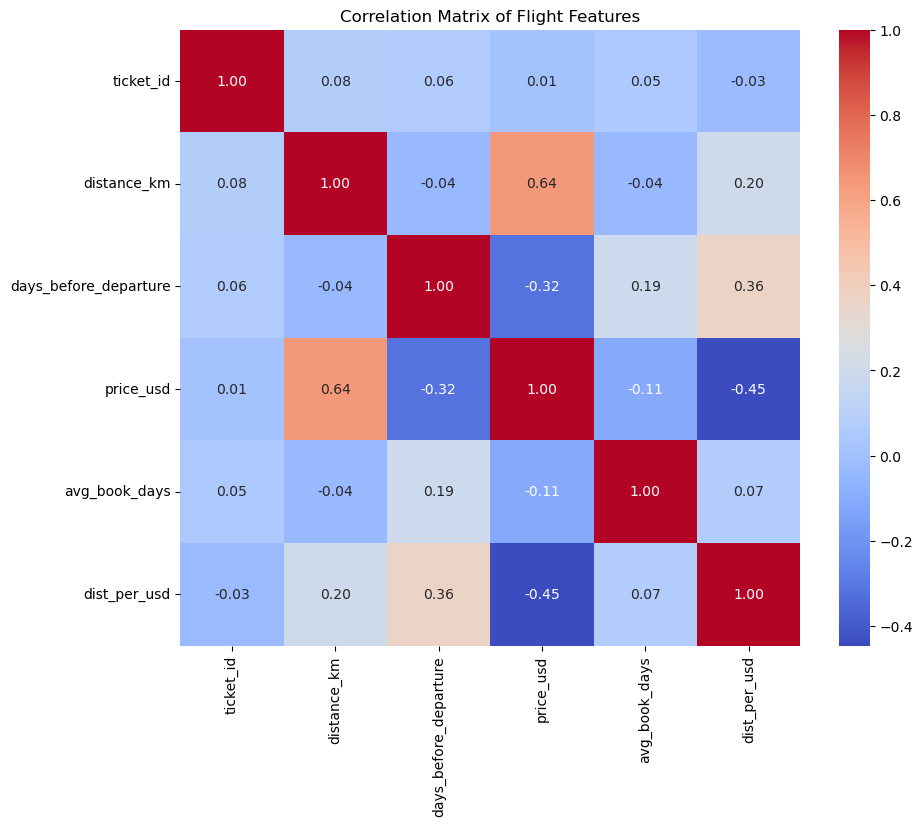

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

#only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Flight Features')
plt.show()